## PHASE 2

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler


def style_axis(ax, title=None, xlabel=None, ylabel=None):
    """Common polish: title, labels, remove top/right spines."""
    if title:
        ax.set_title(title, pad=12)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10.5)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax


# ---- Load dataset ----
df = pd.read_csv('C:/Users/hp/Desktop/Office tasks/Project 3/student_placement_prediction_dataset.csv')

print("=" * 60)
print("1. SHAPE OF THE DATASET")
print("=" * 60)
print(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}\n")

print("=" * 60)
print("2. DATA TYPES")
print("=" * 60)
print(df.dtypes, "\n")

print("=" * 60)
print("3. MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing_Count": missing, "Missing_%": missing_pct})
print(missing_df[missing_df["Missing_Count"] > 0], "\n")

print("=" * 60)
print("4. STATISTICAL SUMMARY")
print("=" * 60)
print(df.describe().T, "\n")

1. SHAPE OF THE DATASET
Rows: 5000   Columns: 23

2. DATA TYPES
Student_ID                     object
Name                           object
Gender                         object
SSC_Percentage                float64
SSC_Board                      object
HSC_Percentage                float64
HSC_Stream                     object
HSC_Board                      object
Degree_Percentage             float64
Degree_Type                    object
Specialization                 object
Work_Experience                object
Internships                     int64
Projects_Count                  int64
Aptitude_Test_Score           float64
Communication_Score           float64
Technical_Score               float64
Certification_Count             int64
Backlogs                        int64
CGPA                          float64
Extracurricular_Activities     object
Placement_Training             object
Placement_Status               object
dtype: object 

3. MISSING VALUES
                     Missing

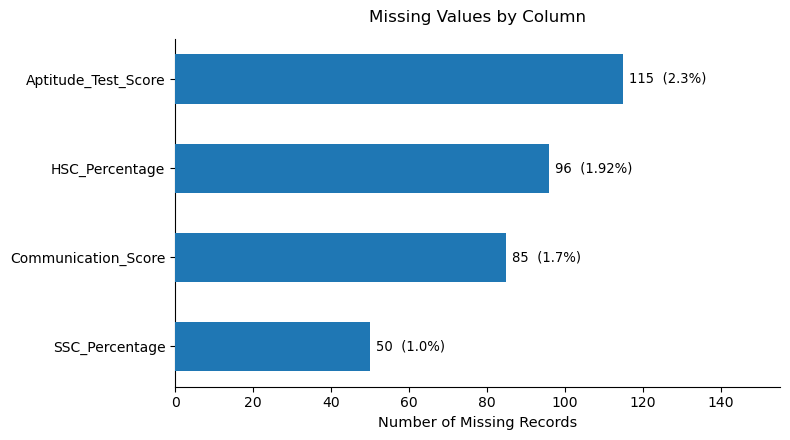

In [2]:
# ----------------------------------------------------------
# 2. MISSING VALUES CHART
# ----------------------------------------------------------
miss_plot = missing_df[missing_df["Missing_Count"] > 0].sort_values("Missing_Count")

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(miss_plot.index, miss_plot["Missing_Count"], height=0.55, zorder=3)
for bar, pct in zip(bars, miss_plot["Missing_%"]):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width())}  ({pct}%)", va="center", fontsize=9.5)
style_axis(ax, "Missing Values by Column", "Number of Missing Records", "")
ax.set_xlim(0, miss_plot["Missing_Count"].max() * 1.35)
plt.tight_layout()
plt.show()

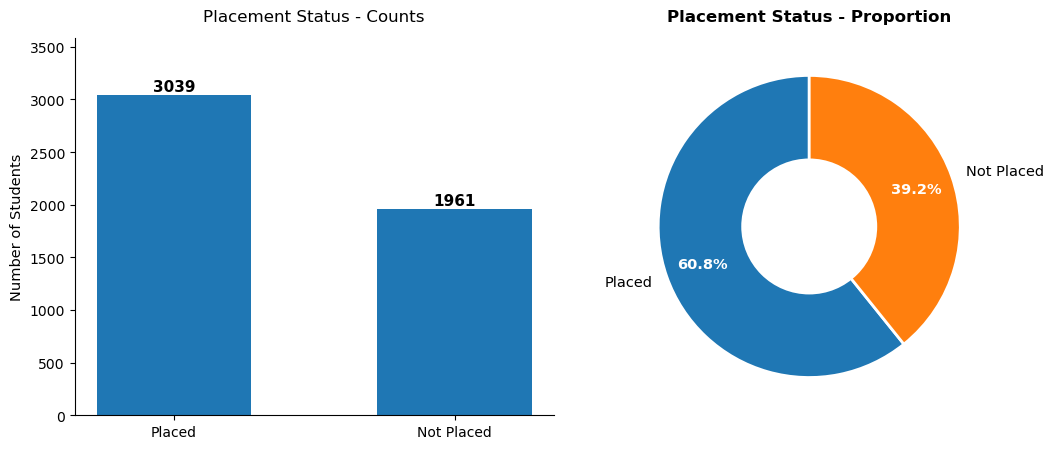

In [3]:
# ----------------------------------------------------------
# 3. TARGET VARIABLE ANALYSIS
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

order = df["Placement_Status"].value_counts().index
counts = df["Placement_Status"].value_counts()
bars = axes[0].bar(order, counts.values, width=0.55)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 40, f"{val}",
                 ha="center", fontsize=11, fontweight="bold")
style_axis(axes[0], "Placement Status - Counts", "", "Number of Students")
axes[0].set_ylim(0, counts.max() * 1.18)

wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=order, autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 10.5}, pctdistance=0.75
)
for at in autotexts:
    at.set_color("white")
    at.set_fontweight("bold")
centre = plt.Circle((0, 0), 0.45, fc="white")
axes[1].add_artist(centre)
axes[1].set_title("Placement Status - Proportion", pad=12, fontweight="bold")

plt.tight_layout()
plt.show()

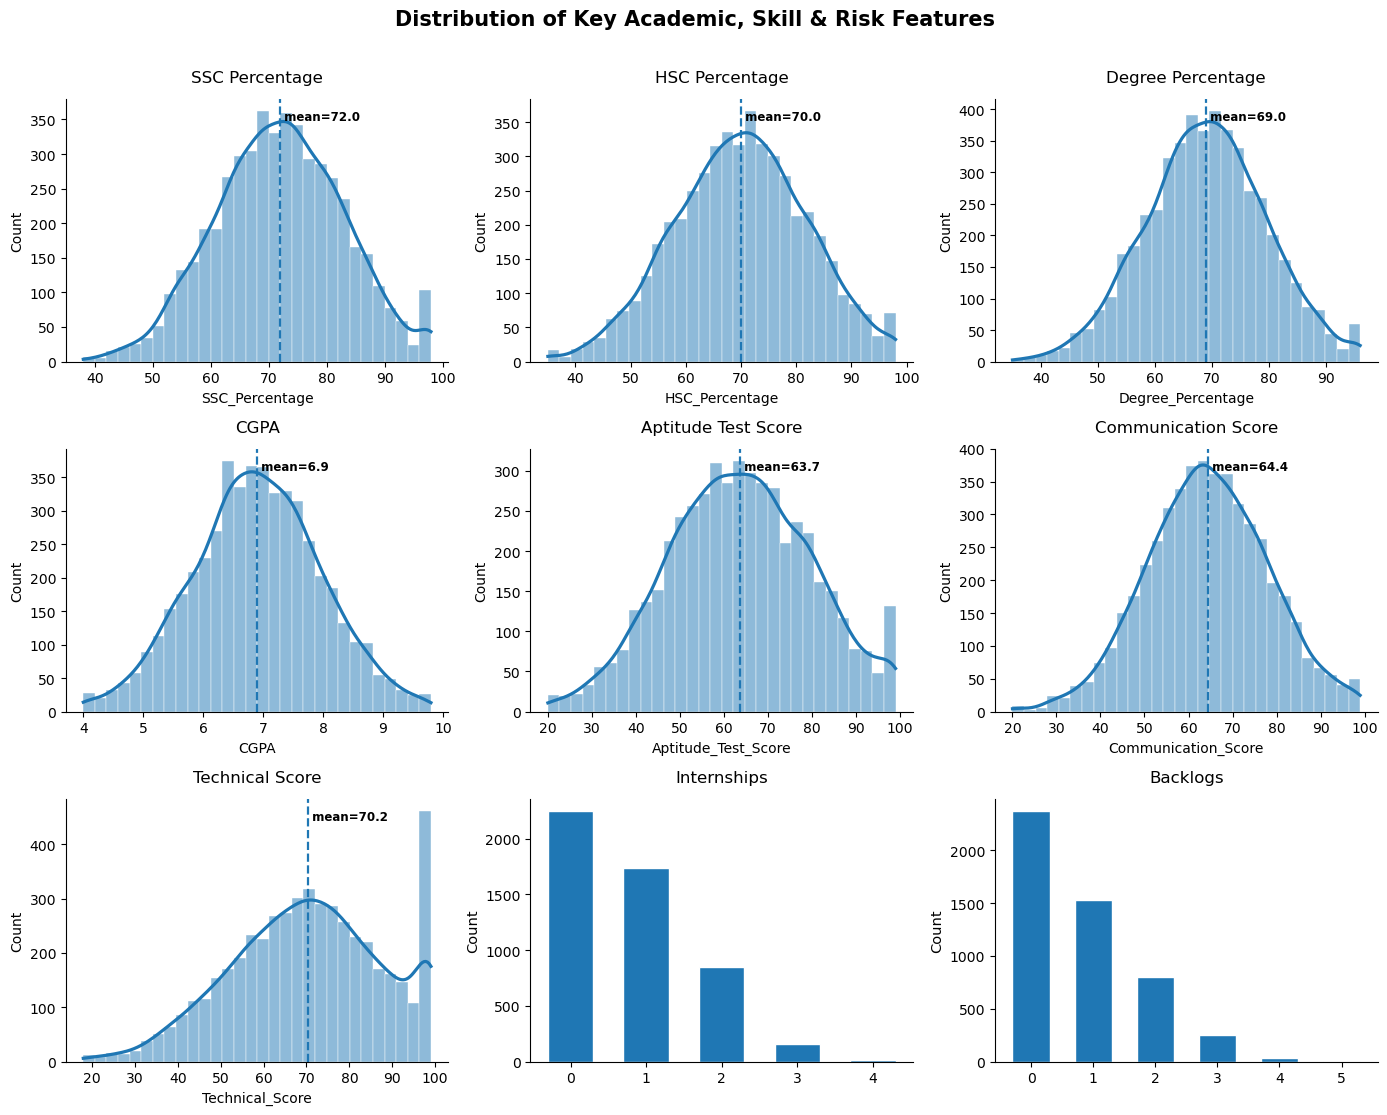

In [4]:
# 4. DISTRIBUTION PLOTS - NUMERIC FEATURES
# ----------------------------------------------------------
numeric_cols = ["SSC_Percentage", "HSC_Percentage", "Degree_Percentage", "CGPA",
                 "Aptitude_Test_Score", "Communication_Score", "Technical_Score"]

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, bins=30, ax=axes[i],
                 edgecolor="white", linewidth=0.3, line_kws={"linewidth": 2.3})
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, linestyle="--", linewidth=1.6)
    axes[i].text(mean_val, axes[i].get_ylim()[1] * 0.92, f" mean={mean_val:.1f}",
                 fontsize=8.5, fontweight="bold")
    style_axis(axes[i], col.replace("_", " "), "", "")

# two extra count-style plots for discrete numeric features in the remaining slots
discrete_cols = ["Internships", "Backlogs"]
for j, col in enumerate(discrete_cols):
    ax = axes[len(numeric_cols) + j]
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, edgecolor="white", width=0.6)
    style_axis(ax, col.replace("_", " "), "", "Count")

for k in range(len(numeric_cols) + len(discrete_cols), len(axes)):
    axes[k].axis("off")
    
fig.suptitle("Distribution of Key Academic, Skill & Risk Features", fontsize=15,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

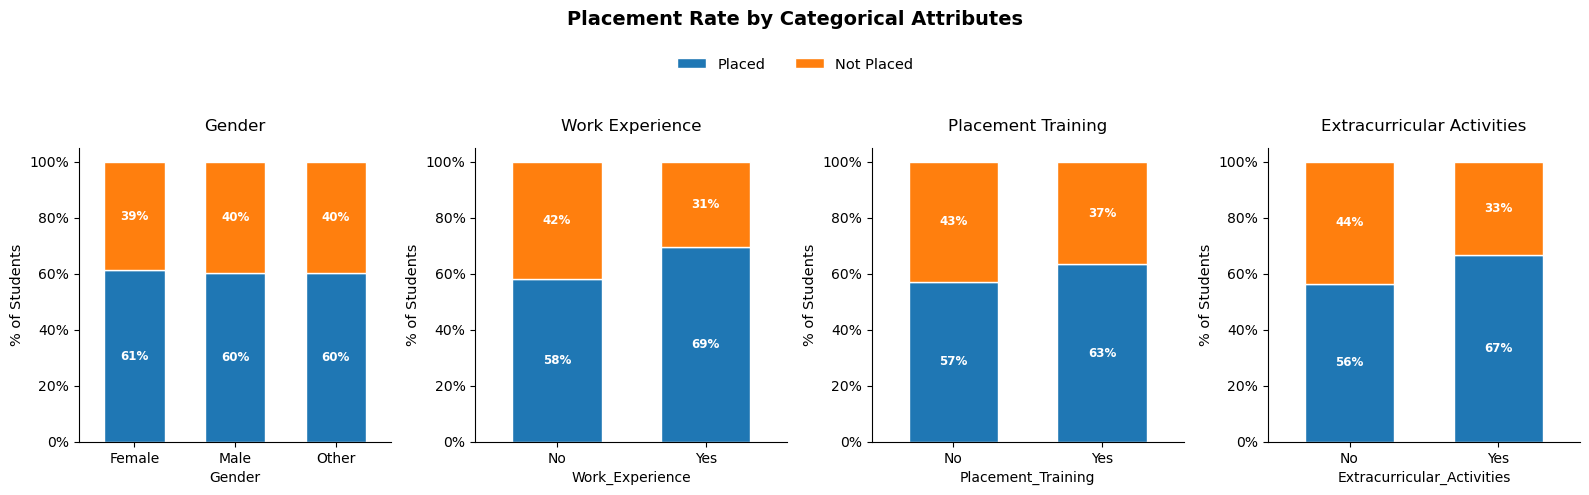

In [5]:
# 5. CATEGORICAL FEATURE BREAKDOWN vs TARGET
# ----------------------------------------------------------
cat_cols = ["Gender", "Work_Experience", "Placement_Training", "Extracurricular_Activities"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.3))
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df["Placement_Status"], normalize="index") * 100
    ct = ct[["Placed", "Not Placed"]]
    ct.plot(kind="bar", stacked=True, ax=axes[i], edgecolor="white", width=0.6, legend=False)
    for cont in axes[i].containers:
        axes[i].bar_label(cont, fmt="%.0f%%", label_type="center",
                           color="white", fontsize=8.5, fontweight="bold")
    style_axis(axes[i], col.replace("_", " "), "", "% of Students")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ["Placed", "Not Placed"], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.06), frameon=False, fontsize=10.5)
fig.suptitle("Placement Rate by Categorical Attributes", fontsize=14, fontweight="bold", y=1.14)
plt.tight_layout()
plt.show()

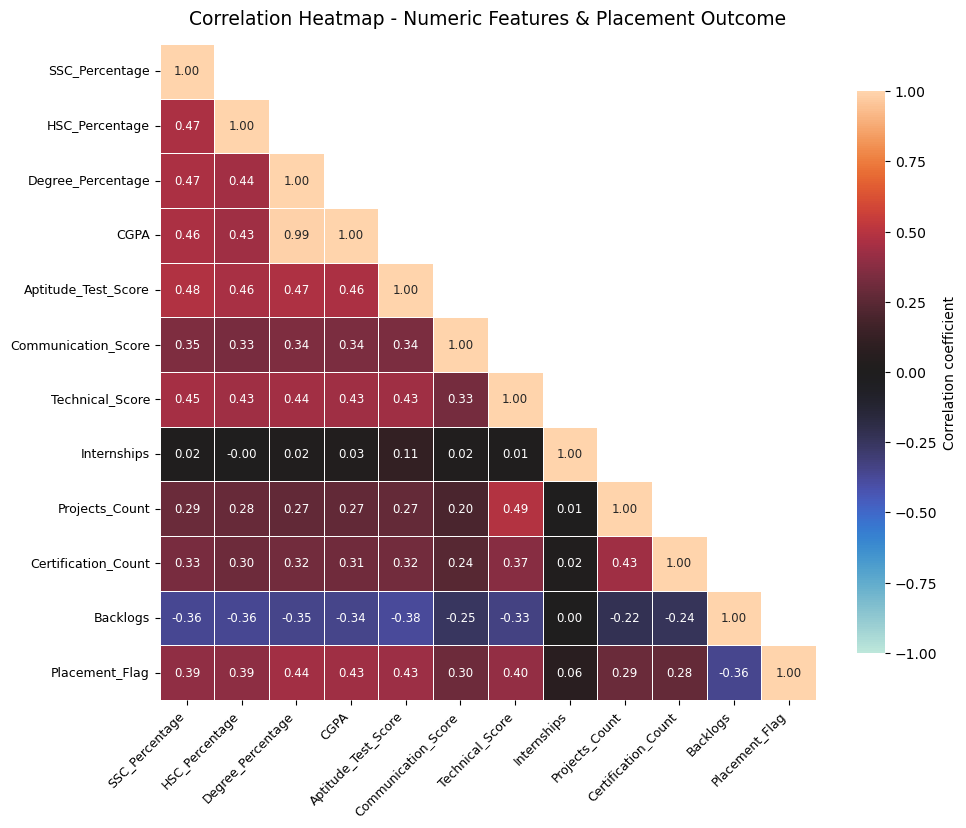

In [6]:
# 6. CORRELATION HEATMAP
# ----------------------------------------------------------
corr_cols = numeric_cols + ["Internships", "Projects_Count", "Certification_Count", "Backlogs"]
df_corr = df.copy()
df_corr["Placement_Flag"] = (df_corr["Placement_Status"] == "Placed").astype(int)
corr_matrix = df_corr[corr_cols + ["Placement_Flag"]].corr()

fig, ax = plt.subplots(figsize=(10, 8.5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", linewidths=0.6, linecolor="white",
            cbar_kws={"shrink": 0.8, "label": "Correlation coefficient"},
            annot_kws={"fontsize": 8.5}, square=True, ax=ax)
ax.set_title("Correlation Heatmap - Numeric Features & Placement Outcome", pad=14, fontsize=13.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

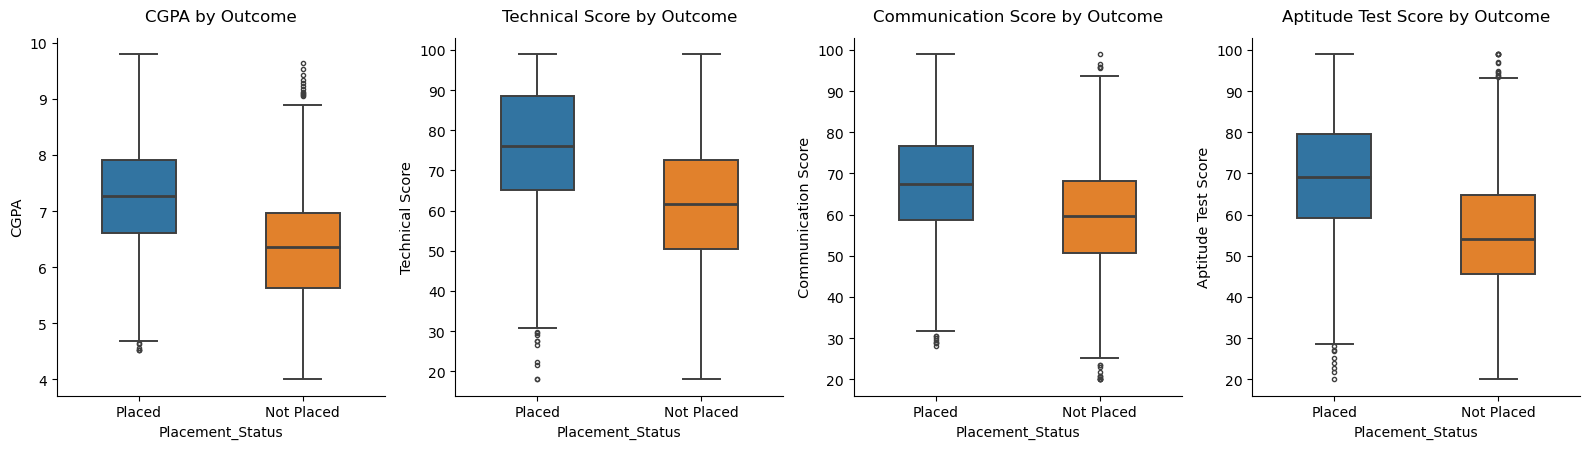

In [7]:
# 7. TOP FEATURES vs PLACEMENT (boxplots)
# ----------------------------------------------------------
top_features = ["CGPA", "Technical_Score", "Communication_Score", "Aptitude_Test_Score"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.6))
for i, col in enumerate(top_features):
    sns.boxplot(data=df, x="Placement_Status", y=col, hue="Placement_Status", ax=axes[i],
                width=0.45, linewidth=1.4, fliersize=3, legend=False,
                medianprops={"linewidth": 2})
    style_axis(axes[i], col.replace("_", " ") + " by Outcome", "", col.replace("_", " "))

plt.tight_layout()
plt.show()

## PHASE3 

In [10]:
def style_axis(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, pad=10)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10.5)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

df = df.drop(columns=["Student_ID", "Name", "Salary_LPA", "Salary_INR"], errors="ignore")
# Student_ID/Name have no predictive value; salary is only known AFTER placement,
# so it must be excluded to avoid target leakage.
print("Shape before preprocessing:", df.shape)

Shape before preprocessing: (5000, 21)



Missing values handled (median imputation):
                     Before  After
SSC_Percentage           50      0
HSC_Percentage           96      0
Aptitude_Test_Score     115      0
Communication_Score      85      0


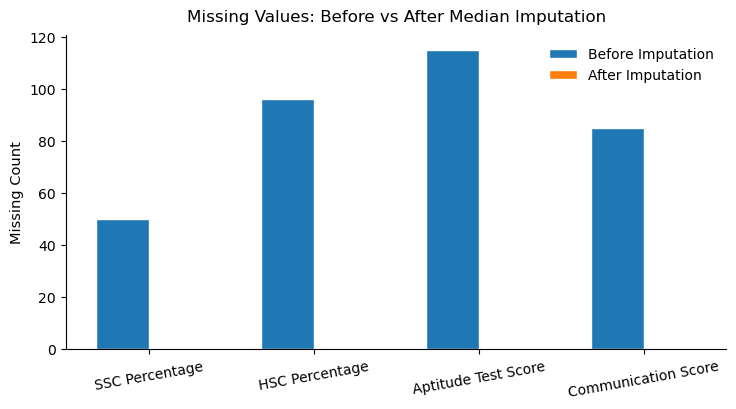

In [11]:
# 2. HANDLE MISSING VALUES
# ----------------------------------------------------------
num_missing_cols = ["SSC_Percentage", "HSC_Percentage", "Aptitude_Test_Score", "Communication_Score"]

before_missing = df[num_missing_cols].isnull().sum()

for col in num_missing_cols:
    df[col] = df[col].fillna(df[col].median())     # median 

after_missing = df[num_missing_cols].isnull().sum()

print("\nMissing values handled (median imputation):")
print(pd.DataFrame({"Before": before_missing, "After": after_missing}))

# --- visual: missing values before vs after ---
fig, ax = plt.subplots(figsize=(7.5, 4.2))
x = np.arange(len(num_missing_cols))
width = 0.32
ax.bar(x - width/2, before_missing.values, width, label="Before Imputation", edgecolor="white")
ax.bar(x + width/2, after_missing.values, width, label="After Imputation", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([c.replace("_", " ") for c in num_missing_cols], rotation=10)
style_axis(ax, "Missing Values: Before vs After Median Imputation", "", "Missing Count")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [12]:
# 3. ENCODE CATEGORICAL -> NUMERICAL
# ----------------------------------------------------------
# 3a. Target variable -> binary label encoding
df["Placement_Status"] = df["Placement_Status"].map({"Placed": 1, "Not Placed": 0})

# 3b. Binary categorical columns -> Label Encoding
binary_cols = ["Work_Experience", "Extracurricular_Activities", "Placement_Training"]
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])   # Yes/No -> 1/0

# 3c. Multi-category nominal columns -> One-Hot Encoding
onehot_cols = ["Gender", "SSC_Board", "HSC_Board", "HSC_Stream", "Degree_Type", "Specialization"]
df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

print(f"\nShape after encoding: {df.shape}  (categorical columns expanded via one-hot encoding)")



Shape after encoding: (5000, 33)  (categorical columns expanded via one-hot encoding)


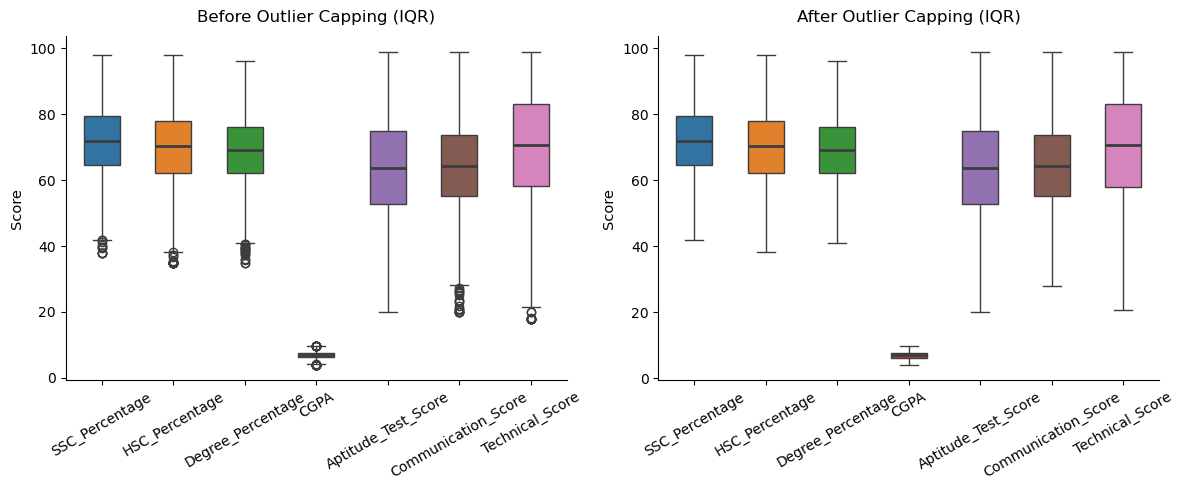

In [13]:
# 4. OUTLIER HANDLING (bonus) - IQR capping on skew-prone numeric cols
# --------------------------------------
outlier_cols = ["SSC_Percentage", "HSC_Percentage", "Degree_Percentage", "CGPA",
                 "Aptitude_Test_Score", "Communication_Score", "Technical_Score"]

before_box = df[outlier_cols].copy()

for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)      # cap rather than drop -> preserves sample size

after_box = df[outlier_cols].copy()

# --- visual: before vs after boxplots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=before_box, ax=axes[0], width=0.5, medianprops={"linewidth": 2})
style_axis(axes[0], "Before Outlier Capping (IQR)", "", "Score")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=after_box, ax=axes[1], width=0.5, medianprops={"linewidth": 2})
style_axis(axes[1], "After Outlier Capping (IQR)", "", "Score")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

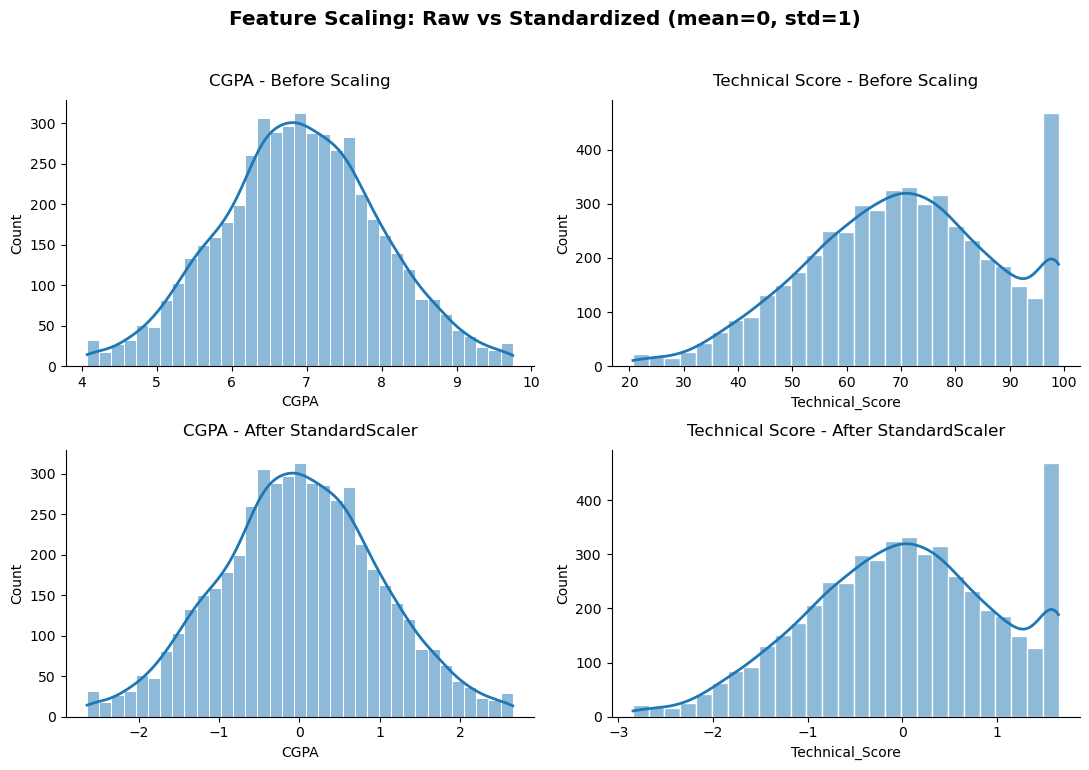


Final preprocessed shape: (5000, 33)


In [14]:
# 5. FEATURE SCALING
# ----------------------------------------------------------
scale_cols = ["SSC_Percentage", "HSC_Percentage", "Degree_Percentage", "CGPA",
              "Aptitude_Test_Score", "Communication_Score", "Technical_Score",
              "Internships", "Projects_Count", "Certification_Count", "Backlogs"]

before_scale = df[scale_cols].copy()

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# --- visual: distribution before vs after scaling (2 representative features) ---
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
sample_cols = ["CGPA", "Technical_Score"]
for i, col in enumerate(sample_cols):
    sns.histplot(before_scale[col], kde=True, ax=axes[0, i], edgecolor="white", line_kws={"linewidth": 2})
    style_axis(axes[0, i], f"{col.replace('_',' ')} - Before Scaling", "", "")
    sns.histplot(df[col], kde=True, ax=axes[1, i], edgecolor="white", line_kws={"linewidth": 2})
    style_axis(axes[1, i], f"{col.replace('_',' ')} - After StandardScaler", "", "")

fig.suptitle("Feature Scaling: Raw vs Standardized (mean=0, std=1)", fontsize=14.5,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nFinal preprocessed shape:", df.shape)

In [15]:
# Save for Phase 4 (Feature Engineering) & Phase 5 (Model Building)
df.to_csv("placement_data_preprocessed.csv", index=False)

## PHASE 4

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif


def style_axis(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, pad=10)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10.5)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

# 1. LOAD PREPROCESSED DATA (output of Phase 3)
# ----------------------------------------------------------
df = pd.read_csv("placement_data_preprocessed.csv")
print("Loaded preprocessed shape:", df.shape)

Loaded preprocessed shape: (5000, 33)



New engineered features added: ['Academic_Avg', 'Skill_Index', 'Experience_Score', 'Backlog_Flag']
                   count       mean        std        min      25%        50%  \
Academic_Avg      5000.0  70.007535   8.842424  38.587500  64.0725  70.157500   
Skill_Index       5000.0  66.130495  11.825023  26.156667  58.3125  66.203333   
Experience_Score  5000.0   4.720600   2.496834   0.000000   3.0000   5.000000   
Backlog_Flag      5000.0   0.525800   0.499384   0.000000   0.0000   1.000000   

                        75%     max  
Academic_Avg      75.900625  97.275  
Skill_Index       74.197500  99.000  
Experience_Score   6.000000  14.000  
Backlog_Flag       1.000000   1.000  


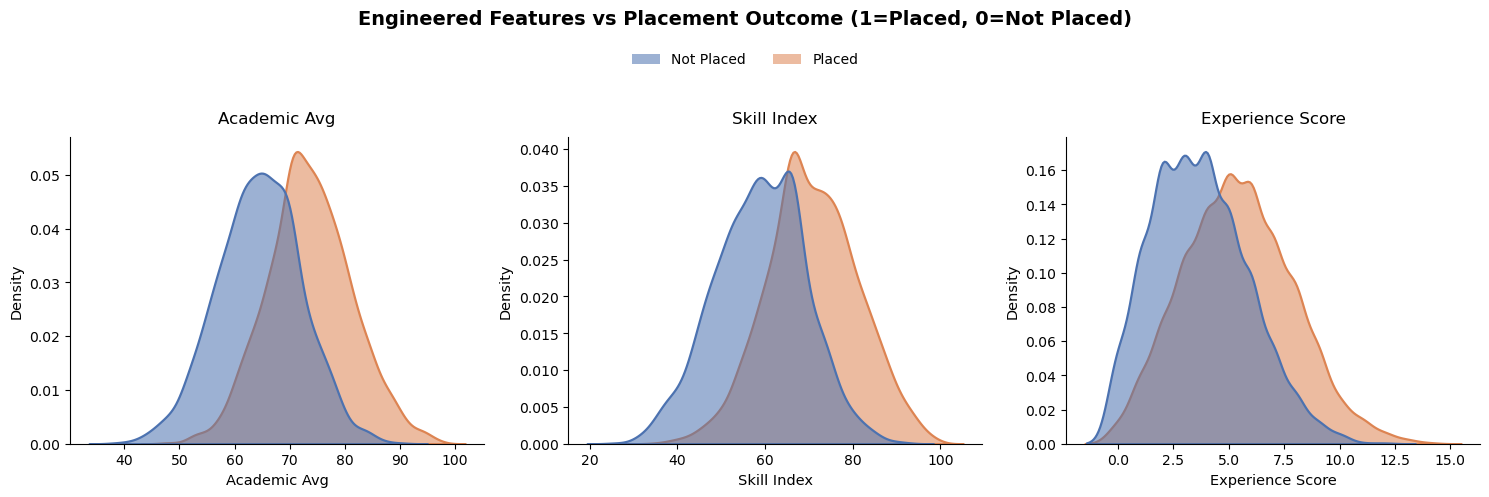

In [17]:
# 2. CREATE NEW FEATURES (Feature Engineering)
# ----------------------------------------------------------
raw = pd.read_csv('C:/Users/hp/Desktop/Office tasks/Project 3/student_placement_prediction_dataset.csv')

# 2a. Academic_Avg: overall academic strength across all 3 stages + CGPA (on 10-scale -> *10)
raw["Academic_Avg"] = (raw["SSC_Percentage"] + raw["HSC_Percentage"] +
                        raw["Degree_Percentage"] + raw["CGPA"] * 10) / 4

# 2b. Skill_Index: combined soft + hard skill score
raw["Skill_Index"] = (raw["Aptitude_Test_Score"] + raw["Communication_Score"] +
                       raw["Technical_Score"]) / 3

# 2c. Experience_Score: practical exposure = internships + projects + certifications
raw["Experience_Score"] = raw["Internships"] + raw["Projects_Count"] + raw["Certification_Count"]

# 2d. Backlog_Flag: binary risk flag (any backlog vs none) — simplifies a skewed count feature
raw["Backlog_Flag"] = (raw["Backlogs"] > 0).astype(int)

engineered_cols = ["Academic_Avg", "Skill_Index", "Experience_Score", "Backlog_Flag"]
df[engineered_cols] = raw[engineered_cols].fillna(raw[engineered_cols].median())

print(f"\nNew engineered features added: {engineered_cols}")
print(df[engineered_cols].describe().T)

# --- visual: distribution of the 3 continuous engineered features by outcome ---
from matplotlib.patches import Patch

palette = {0: "#4C72B0", 1: "#DD8452"}  # Not Placed / Placed

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for i, col in enumerate(["Academic_Avg", "Skill_Index", "Experience_Score"]):
    sns.kdeplot(data=df, x=col, hue="Placement_Status", hue_order=[0, 1],
                ax=axes[i], fill=True, alpha=0.55, linewidth=1.6,
                common_norm=False, palette=palette, legend=False)
    style_axis(axes[i], col.replace("_", " "), col.replace("_", " "), "Density")

handles = [Patch(facecolor=palette[0], alpha=0.55, label="Not Placed"),
           Patch(facecolor=palette[1], alpha=0.55, label="Placed")]
fig.legend(handles=handles, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05), frameon=False)

fig.suptitle("Engineered Features vs Placement Outcome (1=Placed, 0=Not Placed)",
             fontsize=14, fontweight="bold", y=1.12)
plt.tight_layout()
plt.show()

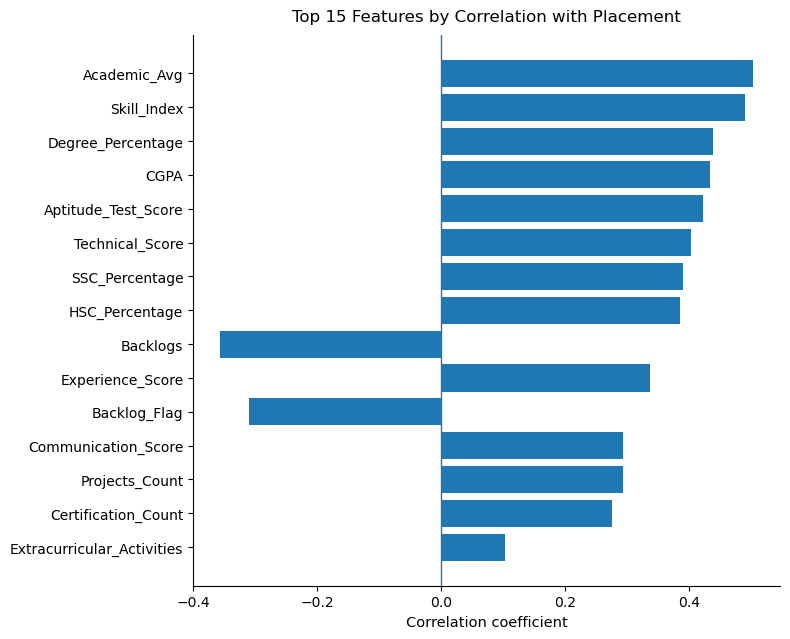

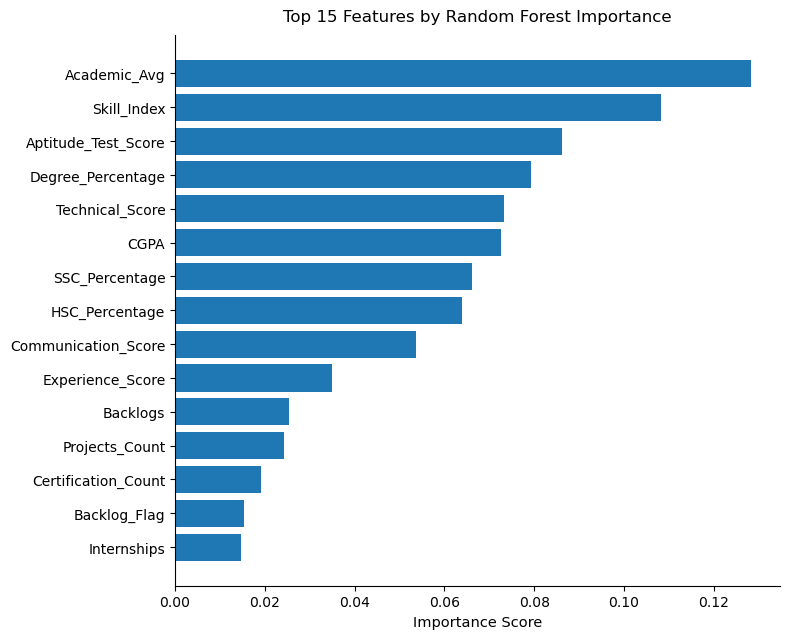

In [18]:
# 3. FEATURE SELECTION
# ----------------------------------------------------------
X = df.drop(columns=["Placement_Status"])
y = df["Placement_Status"]

# 3a. Correlation with target
corr_with_target = X.corrwith(y).sort_values(key=abs, ascending=False)
top_corr = corr_with_target.head(15)

fig, ax = plt.subplots(figsize=(8, 6.5))
bars = ax.barh(top_corr.index[::-1], top_corr.values[::-1], linewidth=0.6)
ax.axvline(0, linewidth=1)
style_axis(ax, "Top 15 Features by Correlation with Placement", "Correlation coefficient", "")
plt.tight_layout()
plt.show()

# 3b. Feature importance via Random Forest
rf_selector = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_selector.fit(X, y)
importances = pd.Series(rf_selector.feature_importances_, index=X.columns).sort_values(ascending=False)
top_importance = importances.head(15)

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(top_importance.index[::-1], top_importance.values[::-1], linewidth=0.6)
style_axis(ax, "Top 15 Features by Random Forest Importance", "Importance Score", "")
plt.tight_layout()
plt.show()

In [19]:
# 3c. SelectKBest (ANOVA F-test) - optional cross-check
skb = SelectKBest(score_func=f_classif, k=15)
skb.fit(X, y)
skb_scores = pd.Series(skb.scores_, index=X.columns).sort_values(ascending=False)

print("\nTop 15 features - Correlation:\n", top_corr.index.tolist())
print("\nTop 15 features - RF Importance:\n", top_importance.index.tolist())
print("\nTop 15 features - SelectKBest (F-test):\n", skb_scores.head(15).index.tolist())

# ----------------------------------------------------------
# 4. FINAL FEATURE SET (union of the 3 methods)
# ----------------------------------------------------------
final_features = sorted(set(top_corr.index) | set(top_importance.index) | set(skb_scores.head(15).index))
print(f"\nFinal selected feature set ({len(final_features)} features):")
print(final_features)

X_final = X[final_features]
X_final_with_target = X_final.copy()
X_final_with_target["Placement_Status"] = y
X_final_with_target.to_csv("placement_data_final_features.csv", index=False)
print("\nSaved final feature set -> placement_data_final_features.csv")


Top 15 features - Correlation:
 ['Academic_Avg', 'Skill_Index', 'Degree_Percentage', 'CGPA', 'Aptitude_Test_Score', 'Technical_Score', 'SSC_Percentage', 'HSC_Percentage', 'Backlogs', 'Experience_Score', 'Backlog_Flag', 'Communication_Score', 'Projects_Count', 'Certification_Count', 'Extracurricular_Activities']

Top 15 features - RF Importance:
 ['Academic_Avg', 'Skill_Index', 'Aptitude_Test_Score', 'Degree_Percentage', 'Technical_Score', 'CGPA', 'SSC_Percentage', 'HSC_Percentage', 'Communication_Score', 'Experience_Score', 'Backlogs', 'Projects_Count', 'Certification_Count', 'Backlog_Flag', 'Internships']

Top 15 features - SelectKBest (F-test):
 ['Academic_Avg', 'Skill_Index', 'Degree_Percentage', 'CGPA', 'Aptitude_Test_Score', 'Technical_Score', 'SSC_Percentage', 'HSC_Percentage', 'Backlogs', 'Experience_Score', 'Backlog_Flag', 'Communication_Score', 'Projects_Count', 'Certification_Count', 'Extracurricular_Activities']

Final selected feature set (16 features):
['Academic_Avg', 'A

## PHASE 5

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, auc)


def style_axis(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, pad=10)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10.5)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax


# ----------------------------------------------------------
# 1. LOAD FINAL FEATURE SET (output of Phase 4)
# ----------------------------------------------------------
df = pd.read_csv("placement_data_final_features.csv")
X = df.drop(columns=["Placement_Status"])
y = df["Placement_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set: {X_train.shape}   Test set: {X_test.shape}")

Train set: (4000, 16)   Test set: (1000, 16)


In [21]:
# 2. TRAIN MODELS
# ----------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1),
}

results = []
conf_matrices = {}
roc_data = {}

for name, model in models.items():
    model.fit(X_train, y_train);
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1 Score": f1})
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, auc(fpr, tpr))

results_df = pd.DataFrame(results).set_index("Model")
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(results_df.round(4))

best_model_name = results_df["F1 Score"].idxmax()
print(f"\nBest performing model (by F1 Score): {best_model_name}")


MODEL COMPARISON
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression     0.769     0.7860  0.8520    0.8177
Decision Tree           0.698     0.7452  0.7648    0.7549
Random Forest           0.758     0.7868  0.8257    0.8058

Best performing model (by F1 Score): Logistic Regression


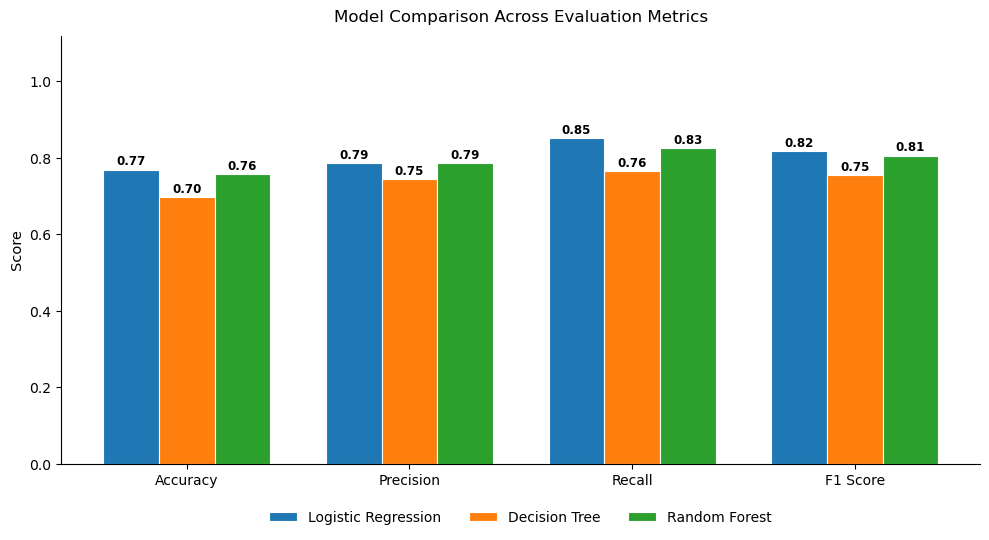

In [22]:
# 3. VISUAL 1 - METRIC COMPARISON (grouped bar chart)
# ----------------------------------------------------------
model_names = list(models.keys())
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5.5))
for i, name in enumerate(model_names):
    vals = results_df.loc[name, metrics].values
    bars = ax.bar(x + (i - 1) * width, vals, width, label=name, edgecolor="white", linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.012, f"{v:.2f}",
                ha="center", fontsize=8.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.12)
style_axis(ax, "Model Comparison Across Evaluation Metrics", "", "Score")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3)
plt.tight_layout()
plt.show()

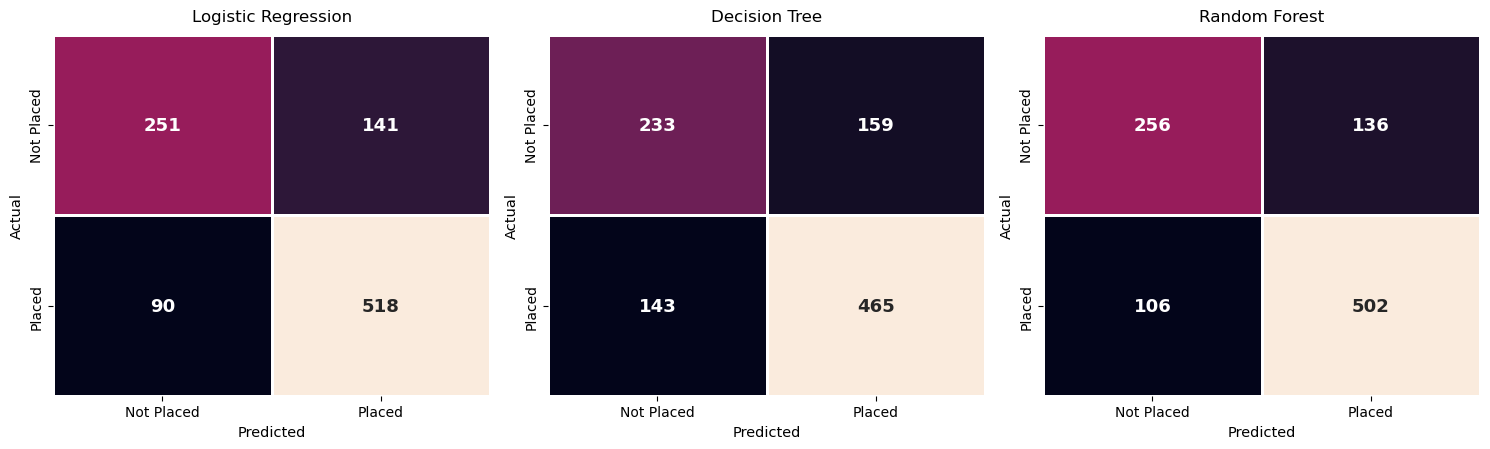

In [23]:
# 4. VISUAL 2 - CONFUSION MATRICES (all 3 models)
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (name, cm) in zip(axes, conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt="d", cbar=False,
                xticklabels=["Not Placed", "Placed"], yticklabels=["Not Placed", "Placed"],
                annot_kws={"fontsize": 13, "fontweight": "bold"}, linewidths=1, linecolor="white", ax=ax)
    style_axis(ax, name, "Predicted", "Actual")

plt.tight_layout()
plt.show()

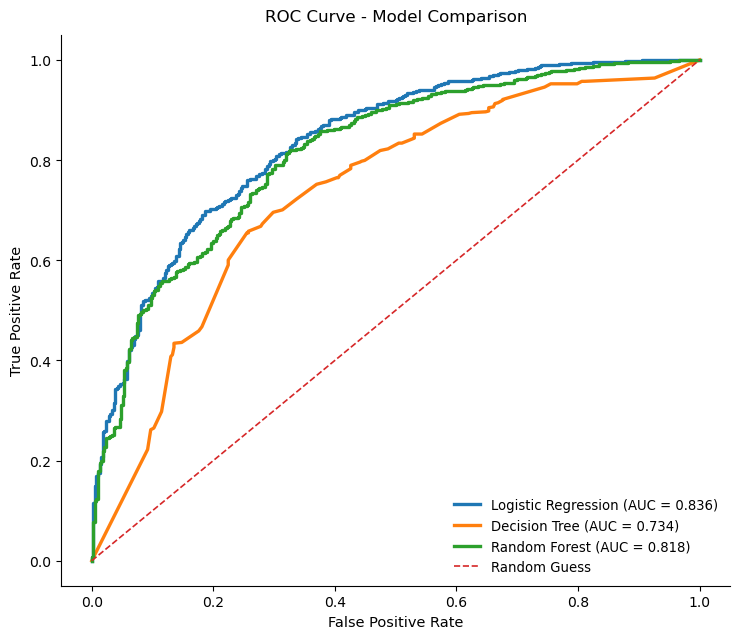

In [24]:
# 5. VISUAL 3 - ROC CURVES
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for name in model_names:
    fpr, tpr, roc_auc = roc_data[name]
    ax.plot(fpr, tpr, linewidth=2.4, label=f"{name} (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.2, label="Random Guess")
style_axis(ax, "ROC Curve - Model Comparison", "False Positive Rate", "True Positive Rate")
ax.legend(frameon=False, loc="lower right", fontsize=9.5)
plt.tight_layout()
plt.show()

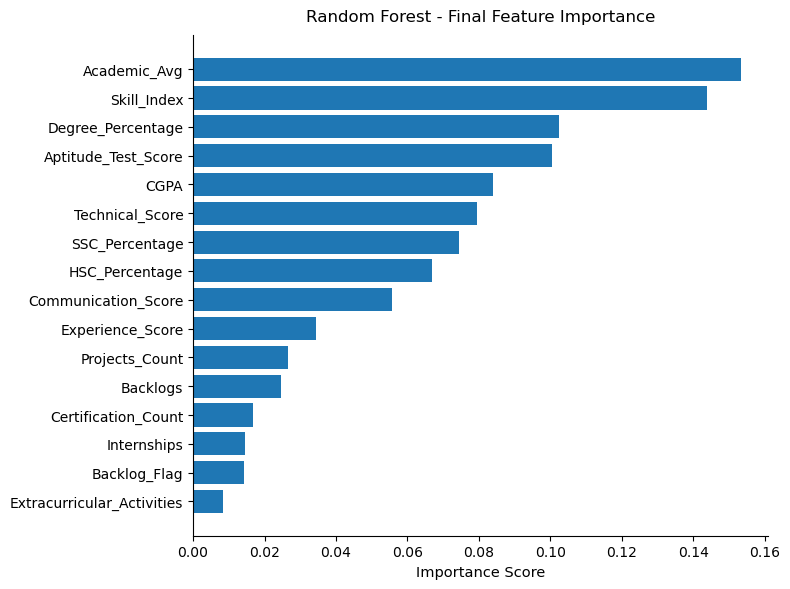


Charts saved: 13_model_comparison.png, 14_confusion_matrices.png,15_roc_curves.png, 16_final_feature_importance.png

Model comparison saved -> model_comparison_results.csv
Selected best model: Logistic Regression


In [25]:
# 6. VISUAL 4 - BEST MODEL FEATURE IMPORTANCE (Random Forest)
# ----------------------------------------------------------
best_model = models["Random Forest"]
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importances.index[::-1], importances.values[::-1], linewidth=0.6)
style_axis(ax, "Random Forest - Final Feature Importance", "Importance Score", "")
plt.tight_layout()
plt.show()

print("\nCharts saved: 13_model_comparison.png, 14_confusion_matrices.png,"
      "15_roc_curves.png, 16_final_feature_importance.png")

# Save comparison table + best model choice for the report
results_df.round(4).to_csv("model_comparison_results.csv")
print(f"\nModel comparison saved -> model_comparison_results.csv")
print(f"Selected best model: {best_model_name}")

In [26]:
# ==========================================================
# PHASE 6: MODEL OPTIMIZATION
# Student Placement Prediction System
# Tools: Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


def style_axis(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, pad=10)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10.5)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax



# 1. REBUILD THE DEPLOYMENT-READY FEATURE SET FROM RAW DATA
# ----------------------------------------------------------
raw = pd.read_csv("C:\\Users\\hp\\Desktop\\Office tasks\\Project 3\\student_placement_prediction_dataset.csv")

# 1a. Missing value handling (median imputation, same as Phase 3)
for col in ["SSC_Percentage", "HSC_Percentage", "Aptitude_Test_Score", "Communication_Score"]:
    raw[col] = raw[col].fillna(raw[col].median())

# 1b. Feature engineering (same as Phase 4)
raw["Academic_Avg"] = (raw["SSC_Percentage"] + raw["HSC_Percentage"] +
                        raw["Degree_Percentage"] + raw["CGPA"] * 10) / 4
raw["Skill_Index"] = (raw["Aptitude_Test_Score"] + raw["Communication_Score"] +
                       raw["Technical_Score"]) / 3
raw["Experience_Score"] = raw["Internships"] + raw["Projects_Count"] + raw["Certification_Count"]
raw["Backlog_Flag"] = (raw["Backlogs"] > 0).astype(int)

# 1c. Encode binary categoricals used in the final feature set
raw["Extracurricular_Activities"] = raw["Extracurricular_Activities"].map({"Yes": 1, "No": 0})
raw["Placement_Status"] = raw["Placement_Status"].map({"Placed": 1, "Not Placed": 0})

FINAL_FEATURES = ["Academic_Avg", "Aptitude_Test_Score", "Backlog_Flag", "Backlogs", "CGPA",
                   "Certification_Count", "Communication_Score", "Degree_Percentage",
                   "Experience_Score", "Extracurricular_Activities", "HSC_Percentage",
                   "Internships", "Projects_Count", "SSC_Percentage", "Skill_Index", "Technical_Score"]

X = raw[FINAL_FEATURES]
y = raw["Placement_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}   Test: {X_test.shape}")
print("Class balance in train set:\n", y_train.value_counts(normalize=True).round(3))

Train: (4000, 16)   Test: (1000, 16)
Class balance in train set:
 Placement_Status
1    0.608
0    0.392
Name: proportion, dtype: float64


In [27]:
# ----------------------------------------------------------
# 2. BASELINE (untuned Logistic Regression, no imbalance handling)
#    -- carried over from Phase 5, the model that WON on F1 there
# ----------------------------------------------------------
baseline_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])
baseline_pipe.fit(X_train, y_train)
y_pred_base = baseline_pipe.predict(X_test)

metrics_base = {
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Precision": precision_score(y_test, y_pred_base),
    "Recall": recall_score(y_test, y_pred_base),
    "F1 Score": f1_score(y_test, y_pred_base),
}
print("\nBaseline Logistic Regression (Phase 5 winner):", {k: round(v, 4) for k, v in metrics_base.items()})



Baseline Logistic Regression (Phase 5 winner): {'Accuracy': 0.77, 'Precision': 0.7872, 'Recall': 0.852, 'F1 Score': 0.8183}


In [28]:
# 3. HYPERPARAMETER TUNING - GridSearchCV with sklearn Pipeline
# (Pipeline bundles scaling + model -> single deployable object)
# ----------------------------------------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=42)),
])

param_grid = [
    {"clf__solver": ["liblinear"], "clf__penalty": ["l1", "l2"],
     "clf__C": [0.01, 0.1, 1, 10, 100], "clf__class_weight": [None, "balanced"]},
    {"clf__solver": ["lbfgs"], "clf__penalty": ["l2"],
     "clf__C": [0.01, 0.1, 1, 10, 100], "clf__class_weight": [None, "balanced"]},
]

grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring="f1", n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)

print("\nBest hyperparameters found:", grid_search.best_params_)
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")

tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)

metrics_tuned = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "F1 Score": f1_score(y_test, y_pred_tuned),
}
print("Tuned Logistic Regression (test set):", {k: round(v, 4) for k, v in metrics_tuned.items()})



Best hyperparameters found: {'clf__C': 0.01, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best CV F1 score: 0.8189
Tuned Logistic Regression (test set): {'Accuracy': 0.769, 'Precision': 0.7852, 'Recall': 0.8536, 'F1 Score': 0.818}


In [29]:
# 4. CLASS IMBALANCE - MANUAL SMOTE (oversample minority class)
def manual_smote(X_arr, y_arr, k=5, random_state=42):
    """Synthetic Minority Over-sampling: interpolate between each minority
    sample and one of its k nearest minority neighbors until classes balance."""
    rng = np.random.default_rng(random_state)
    classes, counts = np.unique(y_arr, return_counts=True)
    minority_class = classes[np.argmin(counts)]
    n_to_generate = counts.max() - counts.min()

    X_min = X_arr[y_arr == minority_class]
    nn = NearestNeighbors(n_neighbors=k + 1).fit(X_min)
    _, neighbor_idx = nn.kneighbors(X_min)

    synthetic = []
    for _ in range(n_to_generate):
        i = rng.integers(0, len(X_min))
        neighbor = neighbor_idx[i, rng.integers(1, k + 1)]   # skip self (index 0)
        gap = rng.random()
        new_point = X_min[i] + gap * (X_min[neighbor] - X_min[i])
        synthetic.append(new_point)

    X_resampled = np.vstack([X_arr, np.array(synthetic)])
    y_resampled = np.concatenate([y_arr, np.full(n_to_generate, minority_class)])
    return X_resampled, y_resampled


In [30]:
# Use the tuned hyperparameters (minus class_weight) on SMOTE-balanced data,
# so the comparison isolates "SMOTE" as the imbalance-handling technique.
best_params = grid_search.best_params_
scaler_for_smote = StandardScaler()
X_train_scaled = scaler_for_smote.fit_transform(X_train)
X_train_smote, y_train_smote = manual_smote(X_train_scaled, y_train.values, k=5)

print(f"\nBefore SMOTE: {np.bincount(y_train)}")
print(f"After  SMOTE: {np.bincount(y_train_smote.astype(int))}")

smote_model = LogisticRegression(
    C=best_params["clf__C"], penalty=best_params["clf__penalty"],
    solver=best_params["clf__solver"], max_iter=2000, random_state=42
)
smote_model.fit(X_train_smote, y_train_smote)

X_test_scaled = scaler_for_smote.transform(X_test)
y_pred_smote = smote_model.predict(X_test_scaled)

metrics_smote = {
    "Accuracy": accuracy_score(y_test, y_pred_smote),
    "Precision": precision_score(y_test, y_pred_smote),
    "Recall": recall_score(y_test, y_pred_smote),
    "F1 Score": f1_score(y_test, y_pred_smote),
}
print("SMOTE-balanced Logistic Regression (test set):", {k: round(v, 4) for k, v in metrics_smote.items()})


Before SMOTE: [1569 2431]
After  SMOTE: [2431 2431]
SMOTE-balanced Logistic Regression (test set): {'Accuracy': 0.753, 'Precision': 0.8264, 'Recall': 0.7516, 'F1 Score': 0.7873}


In [31]:
# 5. VISUAL - BEFORE vs AFTER OPTIMIZATION
# ----------------------------------------------------------
comparison = pd.DataFrame({
    "Baseline LogReg (Phase 5)": metrics_base,
    "Tuned + class_weight (GridSearchCV)": metrics_tuned,
    "Tuned + SMOTE": metrics_smote,
}).T

metric_names = ["Accuracy", "Precision", "Recall", "F1 Score"]
x = np.arange(len(metric_names))
width = 0.26

fig, ax = plt.subplots(figsize=(10.5, 5.8))
for i, row_name in enumerate(comparison.index):
    vals = comparison.loc[row_name, metric_names].values
    bars = ax.bar(x + (i - 1) * width, vals, width, label=row_name, edgecolor="white", linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.012, f"{v:.2f}",
                ha="center", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.15)
style_axis(ax, "Logistic Regression Optimization: Before vs After Tuning & Imbalance Handling", "", "Score")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=9)
plt.tight_layout()
plt.savefig("17_optimization_comparison.png", bbox_inches="tight")
plt.close()

print("\nComparison table:\n", comparison.round(4))



Comparison table:
                                      Accuracy  Precision  Recall  F1 Score
Baseline LogReg (Phase 5)               0.770     0.7872  0.8520    0.8183
Tuned + class_weight (GridSearchCV)     0.769     0.7852  0.8536    0.8180
Tuned + SMOTE                           0.753     0.8264  0.7516    0.7873


In [32]:
# ----------------------------------------------------------
# 6. SELECT FINAL MODEL AND SAVE FOR DEPLOYMENT (Phase 7)
# ----------------------------------------------------------
# Pick whichever of the 3 candidates actually has the best F1 on the test
# set, rather than assuming tuning always wins -- keeps this honest.
all_candidates = {
    "Baseline LogReg (Phase 5)": (baseline_pipe, metrics_base),
    "Tuned + class_weight": (tuned_model, metrics_tuned),
    "Tuned + SMOTE": (smote_model, metrics_smote),   # note: needs external scaler, handled below
}
best_name = max(all_candidates, key=lambda k: all_candidates[k][1]["F1 Score"])
print(f"\nBest configuration by test F1: {best_name}")

if best_name == "Tuned + SMOTE":
    # wrap in a Pipeline so the saved artifact still exposes predict/predict_proba
    # on raw (unscaled) input, consistent with the other two options
    final_pipeline = Pipeline([("scaler", scaler_for_smote), ("clf", smote_model)])
else:
    final_pipeline = all_candidates[best_name][0]

joblib.dump(final_pipeline, "model.pkl")
with open("feature_columns.json", "w") as f:
    json.dump(FINAL_FEATURES, f, indent=2)

print("Saved deployment artifacts: model.pkl, feature_columns.json")
print(f"Final model to deploy: {best_name} -> Pipeline(StandardScaler + LogisticRegression)")


Best configuration by test F1: Baseline LogReg (Phase 5)
Saved deployment artifacts: model.pkl, feature_columns.json
Final model to deploy: Baseline LogReg (Phase 5) -> Pipeline(StandardScaler + LogisticRegression)
